## 1. Data Loading & Parsing

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_val_predict, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

### Import Data

In [2]:
# Import Data from Drive
telecom = pd.read_json(r"C:\Users\Megan Huy\Documents\DSSP\train.json")

In [3]:
# Split Text Column
split_cols = telecom['question'].str.split('|', expand=True)

### Parse Question Column

In [4]:
def parse_question(question):
    drive_marker       = "User plane drive test data as follows："
    engineering_marker = "Engeneering parameters data as follows："

    drive_section      = question.split(drive_marker, 1)[1]
    drive_table_text   = drive_section.split(engineering_marker, 1)[0].strip()
    engineering_table_text = question.split(engineering_marker, 1)[1].strip()

    drive_df       = pd.read_csv(StringIO(drive_table_text), sep="|")
    engineering_df = pd.read_csv(StringIO(engineering_table_text), sep="|")

    return drive_df, engineering_df

### Define Column Names

In [5]:
timestamp    = "Timestamp"
speed        = "GPS Speed (km/h)"
serving_pci  = "5G KPI PCell RF Serving PCI"
serving_rsrp = "5G KPI PCell RF Serving SS-RSRP [dBm]"
serving_sinr = "5G KPI PCell RF Serving SS-SINR [dB]"
throughput   = "5G KPI PCell Layer2 MAC DL Throughput [Mbps]"
rb           = "5G KPI PCell Layer1 DL RB Num (Including 0)"

neighbor_pci_group = [
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 PCI",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 PCI",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 PCI",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 PCI",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 PCI",
]

neighbor_rsrp_group = [
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 1 Filtered Tx BRSRP [dBm]",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 2 Filtered Tx BRSRP [dBm]",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 3 Filtered Tx BRSRP [dBm]",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 4 Filtered Tx BRSRP [dBm]",
    "Measurement PCell Neighbor Cell Top Set(Cell Level) Top 5 Filtered Tx BRSRP [dBm]",
]

### Clean Data Functions

In [6]:
def clean_drive_data(drive_df):
    drive_df = drive_df.rename(columns=lambda x: x.strip())
    drive_df[timestamp] = pd.to_datetime(drive_df[timestamp], errors="coerce")

    drive_numeric_cols = [
        "Longitude", "Latitude", speed, serving_pci,
        serving_rsrp, serving_sinr, throughput, rb,
    ] + neighbor_pci_group + neighbor_rsrp_group

    for col in drive_numeric_cols:
        drive_df[col] = (
            drive_df[col].replace("-", np.nan).replace("", np.nan)
        )
        drive_df[col] = pd.to_numeric(drive_df[col], errors="coerce")

    return drive_df


def clean_engineering_data(engineering_df):
    engineering_df = engineering_df.rename(columns=lambda x: x.strip())

    engineering_numeric_cols = [
        "PCI", "Longitude", "Latitude",
        "Mechanical Downtilt", "Digital Tilt", "Height",
    ]

    for col in engineering_numeric_cols:
        engineering_df[col] = (
            engineering_df[col].replace("-", np.nan).replace("", np.nan)
        )
        engineering_df[col] = pd.to_numeric(engineering_df[col], errors="coerce")

    # Digital Tilt rule: 255 means 6 degrees
    engineering_df["digital_tilt_normalized"] = np.where(
        engineering_df["Digital Tilt"] == 255,
        6,
        engineering_df["Digital Tilt"]
    )

    return engineering_df

---
## 2. Feature Engineering

### Helpers & Constants

In [7]:
#Average Distance Helper

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


def _max_consecutive_true(series: pd.Series) -> int:
    """Longest consecutive run of True in a boolean series."""
    max_run = cur_run = 0
    for val in series:
        if val:
            cur_run += 1
            max_run = max(max_run, cur_run)
        else:
            cur_run = 0
    return max_run


BEAM_SCENARIO_BEAMWIDTH = {"3D": 6, "Wide": 25, "Medium": 12}

LOW_TP_THRESHOLD     = 600   # Mbps
SPEED_THRESHOLD      = 40    # km/h
RB_THRESHOLD         = 160
NEAR_NEIGHBOR_DB     = 3     # dB
DISTANCE_KM_THRESHOLD = 1.0

### Engineer Features Function

In [8]:
def engineer_features(drive_df, engineering_df):
    drive_df       = clean_drive_data(drive_df)
    engineering_df = clean_engineering_data(engineering_df)

    engineering_join = engineering_df.rename(columns={"PCI": "engineering_pci"})
    merged_df = drive_df.merge(
        engineering_join, left_on=serving_pci,
        right_on="engineering_pci", how="left"
    )

    # Distance & tilt
    merged_df["serving_distance_km_row"] = haversine_distance(
        merged_df["Latitude_x"], merged_df["Longitude_x"],
        merged_df["Latitude_y"], merged_df["Longitude_y"],
    )
    merged_df["effective_tilt_row"] = (
        merged_df["Mechanical Downtilt"] + merged_df["digital_tilt_normalized"]
    )
    merged_df["beamwidth_row"] = (
        merged_df["Beam Scenario"].map(BEAM_SCENARIO_BEAMWIDTH).fillna(np.nan)
    )

    # Throughput flag
    low_tp_mask = merged_df[throughput] < LOW_TP_THRESHOLD

    # Neighbor features
    merged_df["best_neighbor_rsrp_row"] = merged_df[neighbor_rsrp_group].max(axis=1)
    merged_df["neighbor_advantage_row"] = (
        merged_df["best_neighbor_rsrp_row"] - merged_df[serving_rsrp]
    )
    close_neighbor_matrix = merged_df[neighbor_rsrp_group].apply(
        lambda col: (col - merged_df[serving_rsrp]).abs() <= NEAR_NEIGHBOR_DB
    )
    merged_df["close_neighbor_count_row"] = close_neighbor_matrix.sum(axis=1)
    merged_df["neighbor_stronger_row"] = (
        merged_df["best_neighbor_rsrp_row"] > merged_df[serving_rsrp]
    ).astype(int)

    # PCI mod-30 conflict
    serving_mod30 = merged_df[serving_pci] % 30
    mod30_conflict_matrix = pd.concat(
        [(merged_df[pci] % 30 == serving_mod30).fillna(False) for pci in neighbor_pci_group],
        axis=1,
    )
    merged_df["mod30_conflict_row"] = mod30_conflict_matrix.any(axis=1).astype(int)
    merged_df["mod30_count_row"]    = mod30_conflict_matrix.sum(axis=1)

    # Flag columns
    merged_df["speed_above_40_row"] = (merged_df[speed] > SPEED_THRESHOLD).astype(int)
    merged_df["rb_below_160_row"]   = (merged_df[rb] < RB_THRESHOLD).astype(int)
    merged_df["sinr_below_5_row"]   = (merged_df[serving_sinr] < 5).astype(int)

    # Handover
    merged_df = merged_df.sort_values(timestamp).reset_index(drop=True)
    merged_df["handover_flag"] = (
        merged_df[serving_pci] != merged_df[serving_pci].shift(1)
    ).astype(int)
    if len(merged_df) > 0:
        merged_df.loc[0, "handover_flag"] = 0

    n_rows = len(merged_df)
    handover_rate_denom = max(n_rows - 1, 1)

    low_tp_count = int(low_tp_mask.sum())

    def _low_tp_mean(col):
        return merged_df.loc[low_tp_mask, col].mean() if low_tp_count > 0 else np.nan
    def _low_tp_max(col):
        return merged_df.loc[low_tp_mask, col].max() if low_tp_count > 0 else np.nan
    def _low_tp_min(col):
        return merged_df.loc[low_tp_mask, col].min() if low_tp_count > 0 else np.nan

    handover_count = int(merged_df["handover_flag"].sum())

    handover_count_low_tp = 0
    if low_tp_count > 0:
        low_tp_pci = merged_df.loc[low_tp_mask, serving_pci]
        handover_count_low_tp = max(int((low_tp_pci != low_tp_pci.shift(1)).sum() - 1), 0)

    avg_neighbor_advantage  = merged_df["neighbor_advantage_row"].mean()
    overlap_ratio           = (merged_df["close_neighbor_count_row"] > 0).mean()
    avg_sinr                = merged_df[serving_sinr].mean()
    avg_serving_tilt        = merged_df["effective_tilt_row"].mean()
    min_rsrp                = merged_df[serving_rsrp].min()

    txrx_mode = (
        merged_df["TxRx Mode"].mode().iloc[0]
        if "TxRx Mode" in merged_df.columns and not merged_df["TxRx Mode"].isna().all()
        else "Unknown"
    )
    antenna_model = (
        merged_df["Antenna Model"].mode().iloc[0]
        if "Antenna Model" in merged_df.columns and not merged_df["Antenna Model"].isna().all()
        else "Unknown"
    )

    feature_dict = {
        # Throughput
        "avg_throughput":         merged_df[throughput].mean(),
        "min_throughput":         merged_df[throughput].min(),
        "std_throughput":         merged_df[throughput].std(),
        "low_tp_count":           low_tp_count,
        "low_tp_ratio":           low_tp_mask.mean(),
        "avg_throughput_low_tp":  _low_tp_mean(throughput),
        "consecutive_low_tp_max": _max_consecutive_true(low_tp_mask),
        # Speed
        "max_speed":              merged_df[speed].max(),
        "pct_speed_above_40":     merged_df["speed_above_40_row"].mean(),
        "avg_speed_low_tp":       _low_tp_mean(speed),
        "max_speed_low_tp":       _low_tp_max(speed),
        # Mobility
        "num_unique_serving_pci": merged_df[serving_pci].nunique(),
        "handover_count":         handover_count,
        "handover_rate":          handover_count / handover_rate_denom,
        "handover_count_low_tp":  handover_count_low_tp,
        # RSRP
        "avg_rsrp":               merged_df[serving_rsrp].mean(),
        "min_rsrp":               min_rsrp,
        "avg_rsrp_low_tp":        _low_tp_mean(serving_rsrp),
        # SINR
        "avg_sinr":               avg_sinr,
        "min_sinr":               merged_df[serving_sinr].min(),
        "std_sinr":               merged_df[serving_sinr].std(),
        "pct_sinr_below_5":       merged_df["sinr_below_5_row"].mean(),
        "avg_sinr_low_tp":        _low_tp_mean(serving_sinr),
        "min_sinr_low_tp":        _low_tp_min(serving_sinr),
        # RB
        "avg_rb":                 merged_df[rb].mean(),
        "min_rb":                 merged_df[rb].min(),
        "avg_rb_low_tp":          _low_tp_mean(rb),
        "min_rb_low_tp":          _low_tp_min(rb),
        "pct_rb_below_160":       merged_df["rb_below_160_row"].mean(),
        # Neighbor signal
        "avg_neighbor_advantage":  avg_neighbor_advantage,
        "max_neighbor_advantage":  merged_df["neighbor_advantage_row"].max(),
        "neighbor_stronger_ratio": merged_df["neighbor_stronger_row"].mean(),
        "avg_close_neighbor_count":merged_df["close_neighbor_count_row"].mean(),
        "overlap_ratio":           overlap_ratio,
        # PCI mod-30
        "same_mod30_exists":      int(merged_df["mod30_conflict_row"].any()),
        "same_mod30_count":       int(merged_df["mod30_count_row"].sum()),
        "same_mod30_ratio":       merged_df["mod30_conflict_row"].mean(),
        # Serving-cell engineering
        "avg_serving_tilt":        avg_serving_tilt,
        "max_serving_tilt":        merged_df["effective_tilt_row"].max(),
        "avg_serving_beamwidth":   merged_df["beamwidth_row"].mean(),
        "avg_serving_height":      merged_df["Height"].mean(),
        "avg_serving_distance_km": merged_df["serving_distance_km_row"].mean(),
        "max_serving_distance_km": merged_df["serving_distance_km_row"].max(),
        "pct_distance_gt_1km":     (merged_df["serving_distance_km_row"] > DISTANCE_KM_THRESHOLD).mean(),
        "avg_distance_low_tp":     _low_tp_mean("serving_distance_km_row"),
        # Categorical
        "txrx_mode":              txrx_mode,
        "antenna_model":          antenna_model,
        # Interaction / derived
        "throughput_per_sinr":    merged_df[throughput].mean() / (avg_sinr + 1) if pd.notna(avg_sinr) else np.nan,
        "tilt_rsrp_interaction":  avg_serving_tilt * abs(min_rsrp) if pd.notna(min_rsrp) else np.nan,
        "neighbor_competition":   avg_neighbor_advantage * overlap_ratio,
    }

    return feature_dict

### Build Feature DataFrame

In [9]:
features = []

for idx, row in telecom.iterrows():
    drive_df, engineering_df = parse_question(row["question"])
    feature_dict = engineer_features(drive_df, engineering_df)
    feature_dict["answer"]     = row["answer"]
    feature_dict["row_number"] = idx
    features.append(feature_dict)

new_feature_df = pd.DataFrame(features)
print(new_feature_df.shape)
new_feature_df.head()

(2400, 52)


,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,avg_speed_low_tp,...,max_serving_distance_km,pct_distance_gt_1km,avg_distance_low_tp,txrx_mode,antenna_model,throughput_per_sinr,tilt_rsrp_interaction,neighbor_competition,answer,row_number
0,847.792,334.00,407.163069,4,0.4,424.7125,4,33,0.0,12.75,...,2.774421,0.4,2.771672,64T64R,NR AAU 2,64.925103,1164.372,-1.7334,C2,0
1,850.051,388.58,345.211857,4,0.4,470.3825,4,33,0.0,12.75,...,0.068577,0.0,0.044401,32T32R,NR AAU 1,69.579357,2445.844,-0.0000,C1,1
2,671.739,258.08,295.071300,4,0.4,338.5225,4,36,0.0,16.00,...,1.698408,0.4,1.698408,32T32R,NR AAU 3,30.204092,1671.780,-0.0000,C2,2
3,921.430,407.35,399.562308,4,0.4,459.8275,4,32,0.0,8.75,...,2.976701,0.4,2.957331,64T64R,NR AAU 2,78.768165,1090.680,-0.0000,C2,3
4,789.406,319.87,366.988478,4,0.4,404.2275,4,32,0.0,22.75,...,0.263115,0.0,0.183851,32T32R,NR AAU 1,71.712028,1196.300,-1.4376,C5,4


### One-Hot Encode Engineering Categorical Columns

In [10]:
all_engineering_tables = []

for i in range(len(telecom)):
    question = telecom.loc[i, "question"]
    drive_df, engineering_df = parse_question(question)
    engineering_df["row_number"] = i
    all_engineering_tables.append(engineering_df)

all_engineering = pd.concat(all_engineering_tables, ignore_index=True)

cat_cols = ["Beam Scenario", "TxRx Mode", "Antenna Model"]
all_engineering_encoded = pd.get_dummies(all_engineering, columns=cat_cols, dtype=int)

one_hot_cols = [c for c in all_engineering_encoded.columns if c not in all_engineering.columns]
one_hot_by_question = (
    all_engineering_encoded.groupby("row_number")[one_hot_cols].max().reset_index()
)

final_df = new_feature_df.merge(one_hot_by_question, on="row_number", how="left")
final_df = final_df.drop(columns=["row_number"], errors="ignore")

cols = final_df.columns.tolist()
cols.remove("answer")
cols.insert(0, "answer")
final_df = final_df[cols]

print(final_df.shape)
final_df.head()

(2400, 72)


,answer,avg_throughput,min_throughput,std_throughput,low_tp_count,low_tp_ratio,avg_throughput_low_tp,consecutive_low_tp_max,max_speed,pct_speed_above_40,...,Beam Scenario_SCENARIO_9,TxRx Mode_2T2R,TxRx Mode_32T32R,TxRx Mode_4T4R,TxRx Mode_64T64R,TxRx Mode_8T8R,Antenna Model_NR AAU 1,Antenna Model_NR AAU 2,Antenna Model_NR AAU 3,Antenna Model_Other
0,C2,847.792,334.00,407.163069,4,0.4,424.7125,4,33,0.0,...,1,0,1,0,1,0,1,1,0,0
1,C1,850.051,388.58,345.211857,4,0.4,470.3825,4,33,0.0,...,1,0,1,1,1,0,1,1,0,1
2,C2,671.739,258.08,295.071300,4,0.4,338.5225,4,36,0.0,...,1,0,1,0,1,0,0,1,1,0
3,C2,921.430,407.35,399.562308,4,0.4,459.8275,4,32,0.0,...,1,0,1,1,1,0,0,1,1,1
4,C5,789.406,319.87,366.988478,4,0.4,404.2275,4,32,0.0,...,0,0,1,0,1,0,1,1,1,0


---
## 3. Check VIF

### Compute VIF on All Numeric Features

In [11]:
X = final_df.drop(columns=["answer"])
X = X.drop(columns=["txrx_mode", "antenna_model"], errors="ignore")
X_numeric = X.select_dtypes(include=[np.number])
X_numeric = X_numeric.fillna(X_numeric.median()).fillna(0)
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan).fillna(0)
X_numeric = X_numeric.loc[:, X_numeric.nunique() > 1]

X_const = add_constant(X_numeric)

# Zero variance check
zero_var_cols = X_numeric.columns[X_numeric.std() == 0].tolist()
print(f"Zero variance columns ({len(zero_var_cols)}): {zero_var_cols}")
X_numeric = X_numeric.loc[:, X_numeric.std() > 0]

vif_df = pd.DataFrame({
    "Feature": X_const.columns,
    "VIF": [
        variance_inflation_factor(X_const.values, i)
        for i in range(X_const.shape[1])
    ]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(f"Features with VIF >= 10: {len(vif_df[vif_df['VIF'] >= 10])}")
vif_df

Zero variance columns (0): []
Features with VIF >= 10: 39


,Feature,VIF
0,num_unique_serving_pci,inf
1,handover_count,inf
2,low_tp_count,inf
3,low_tp_ratio,inf
4,pct_distance_gt_1km,inf
...,...,...
61,Beam Scenario_SCENARIO_7,1.539291
62,Beam Scenario_SCENARIO_2,1.529200
63,Beam Scenario_SCENARIO_14,1.269094
64,throughput_per_sinr,1.131505


### Iterative VIF Removal (Threshold = 10)

In [12]:
def iterative_vif_removal(X, threshold=10):
    # Drop zero variance columns first
    zero_var = X.columns[X.std() == 0].tolist()
    if zero_var:
        print(f"Dropping {len(zero_var)} zero-variance columns: {zero_var}")
    
    cols    = [c for c in X.columns if c not in zero_var]
    dropped = []

    while True:
        X_const    = add_constant(pd.DataFrame(X[cols]))
        vif_series = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns
        ).drop("const")

        max_vif = vif_series.max()
        if max_vif < threshold:
            break

        worst = vif_series.idxmax()
        dropped.append((worst, round(max_vif, 2)))
        cols.remove(worst)
        print(f"Dropped: {worst} (VIF={max_vif:.2f}) — {len(cols)} features remaining")

    print(f"\nDone. {len(cols)} kept, {len(dropped)} dropped.")
    return X[cols], dropped


X_vif_clean, dropped_features = iterative_vif_removal(X_numeric)

Dropped: low_tp_count (VIF=inf) — 64 features remaining
Dropped: num_unique_serving_pci (VIF=inf) — 63 features remaining
Dropped: handover_count (VIF=inf) — 62 features remaining
Dropped: tilt_rsrp_interaction (VIF=2231.63) — 61 features remaining
Dropped: max_serving_distance_km (VIF=727.81) — 60 features remaining
Dropped: avg_rb_low_tp (VIF=259.82) — 59 features remaining
Dropped: avg_distance_low_tp (VIF=149.24) — 58 features remaining
Dropped: overlap_ratio (VIF=105.80) — 57 features remaining
Dropped: min_sinr_low_tp (VIF=88.34) — 56 features remaining
Dropped: avg_sinr (VIF=70.74) — 55 features remaining
Dropped: avg_throughput (VIF=56.12) — 54 features remaining
Dropped: pct_distance_gt_1km (VIF=46.41) — 53 features remaining
Dropped: low_tp_ratio (VIF=34.71) — 52 features remaining
Dropped: min_sinr (VIF=34.18) — 51 features remaining
Dropped: Antenna Model_Other (VIF=30.75) — 50 features remaining
Dropped: avg_rb (VIF=24.83) — 49 features remaining
Dropped: same_mod30_ratio 

### Comment

24 variables were dropped. 41 Variables are kept.

### Verify VIF After Cleaning

In [13]:
X_recheck      = X_vif_clean.fillna(X_vif_clean.median()).fillna(0)
X_recheck      = X_recheck.replace([np.inf, -np.inf], np.nan).fillna(0)
X_recheck      = X_recheck.loc[:, X_recheck.nunique() > 1]
X_const_re     = add_constant(X_recheck)

vif_recheck = pd.DataFrame({
    "Feature": X_const_re.columns,
    "VIF": [
        variance_inflation_factor(X_const_re.values, i)
        for i in range(X_const_re.shape[1])
    ]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(f"Features with VIF >= 10 after cleaning: {len(vif_recheck[vif_recheck['VIF'] >= 10])}")
vif_recheck

Features with VIF >= 10 after cleaning: 1


,Feature,VIF
0,const,4421.698127
1,min_rb,8.236360
2,pct_rb_below_160,7.928927
3,avg_rsrp,7.002270
4,avg_serving_tilt,6.839922
5,pct_speed_above_40,6.616159
6,max_speed_low_tp,6.426337
7,max_serving_tilt,5.899266
8,avg_rsrp_low_tp,5.074743
9,avg_sinr_low_tp,4.551578


### Comment

After dropping the features with VIF of >10, we have features that show moderate (5-9), low (1-4), or no multicollinearity.

In [14]:
remaining_features = [
    "min_rb", "pct_rb_below_160", "avg_rsrp", "avg_serving_tilt",
    "pct_speed_above_40", "max_speed_low_tp", "max_serving_tilt",
    "avg_rsrp_low_tp", "avg_sinr_low_tp", "max_neighbor_advantage",
    "avg_close_neighbor_count", "neighbor_stronger_ratio", "same_mod30_count",
    "same_mod30_exists", "pct_sinr_below_5", "std_sinr", "avg_serving_height",
    "neighbor_competition", "Beam Scenario_SCENARIO_4", "Antenna Model_NR AAU 1",
    "Beam Scenario_SCENARIO_13", "TxRx Mode_32T32R", "Antenna Model_NR AAU 3",
    "Beam Scenario_SCENARIO_3", "min_rsrp", "avg_throughput_low_tp",
    "Beam Scenario_SCENARIO_1", "Beam Scenario_SCENARIO_8",
    "Beam Scenario_SCENARIO_12", "handover_rate", "Beam Scenario_SCENARIO_9",
    "Beam Scenario_SCENARIO_7", "Beam Scenario_SCENARIO_2", "TxRx Mode_4T4R",
    "std_throughput", "consecutive_low_tp_max", "TxRx Mode_2T2R",
    "avg_serving_distance_km", "TxRx Mode_8T8R", "Beam Scenario_SCENARIO_14",
    "throughput_per_sinr"
]

In [15]:
def make_formula(target, features):
    terms = [f'Q("{f}")' if " " in f else f for f in features]
    return f"{target} ~ " + " + ".join(terms)

In [16]:
import statsmodels.formula.api as smf

In [17]:
final_df[remaining_features].isnull().sum()

min_rb                       0
pct_rb_below_160             0
avg_rsrp                     0
avg_serving_tilt             0
pct_speed_above_40           0
max_speed_low_tp             3
max_serving_tilt             0
avg_rsrp_low_tp              3
avg_sinr_low_tp              3
max_neighbor_advantage       0
avg_close_neighbor_count     0
neighbor_stronger_ratio      0
same_mod30_count             0
same_mod30_exists            0
pct_sinr_below_5             0
std_sinr                     0
avg_serving_height           0
neighbor_competition         0
Beam Scenario_SCENARIO_4     0
Antenna Model_NR AAU 1       0
Beam Scenario_SCENARIO_13    0
TxRx Mode_32T32R             0
Antenna Model_NR AAU 3       0
Beam Scenario_SCENARIO_3     0
min_rsrp                     0
avg_throughput_low_tp        3
Beam Scenario_SCENARIO_1     0
Beam Scenario_SCENARIO_8     0
Beam Scenario_SCENARIO_12    0
handover_rate                0
Beam Scenario_SCENARIO_9     0
Beam Scenario_SCENARIO_7     0
Beam Sce

Three rows contained NaN values in the low throughput features (max_speed_low_tp, 
avg_rsrp_low_tp, avg_sinr_low_tp, avg_throughput_low_tp). These occurred because 
those observations had no low throughput events, leaving nothing to compute. 
Since the absence of low throughput events is meaningfully zero, NaN values were 
filled with 0 prior to modeling.

In [18]:
low_tp_cols = ["max_speed_low_tp", "avg_rsrp_low_tp", "avg_sinr_low_tp", "avg_throughput_low_tp"]
final_df[low_tp_cols] = final_df[low_tp_cols].fillna(0)

# C1 Logistic Regression

In [19]:
# C1 - Model
telecom_C1 = final_df[remaining_features + ["answer"]].copy()
telecom_C1["is_C1"] = (telecom_C1["answer"] == "C1").astype(int)
formula_C1 = make_formula("is_C1", remaining_features)
log_reg_C1 = smf.logit(formula_C1, data=telecom_C1).fit()
print(log_reg_C1.summary())

         Current function value: 0.058225
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  is_C1   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2358
Method:                           MLE   Df Model:                           41
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.8320
Time:                        18:45:34   Log-Likelihood:                -139.74
converged:                      False   LL-Null:                       -831.64
Covariance Type:            nonrobust   LLR p-value:                1.491e-263
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                        -97.7440   3.78e+04     -0.003      0.998   -7.42e+04     7.4e+04
min_r

In [20]:
#Prediction Probabilities
predProbs_C1 = log_reg_C1.predict(telecom_C1[remaining_features])
preds_C1 = list(map(round, predProbs_C1))
actual_C1 = telecom_C1["is_C1"]
pd.DataFrame({"actual": actual_C1, "pred_prob": predProbs_C1, "pred_class": preds_C1})

,actual,pred_prob,pred_class
0,0,3.515948e-13,0
1,1,9.886494e-01,1
2,0,1.207225e-12,0
3,0,2.503651e-11,0
4,0,7.939833e-28,0
...,...,...,...
2395,0,1.474753e-01,0
2396,0,1.160043e-10,0
2397,0,6.016739e-27,0
2398,1,9.955169e-01,1


# C2

In [21]:
# C2 - Model
telecom_C2 = final_df[remaining_features + ["answer"]].copy()
telecom_C2["is_C2"] = (telecom_C2["answer"] == "C2").astype(int)
formula_C2 = make_formula("is_C2", remaining_features)
log_reg_C2 = smf.logit(formula_C2, data=telecom_C2).fit(method="bfgs")
print(log_reg_C2.summary())

         Current function value: 0.000541
         Iterations: 35
         Function evaluations: 48
         Gradient evaluations: 43
                           Logit Regression Results                           
Dep. Variable:                  is_C2   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2358
Method:                           MLE   Df Model:                           41
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.9986
Time:                        18:45:35   Log-Likelihood:                -1.2980
converged:                      False   LL-Null:                       -942.42
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0

In [22]:
# C2 - Predictions
predProbs_C2 = log_reg_C2.predict(telecom_C2[remaining_features])
preds_C2 = list(map(round, predProbs_C2))
actual_C2 = telecom_C2["is_C2"]
pd.DataFrame({"actual": actual_C2, "pred_prob": predProbs_C2, "pred_class": preds_C2})

,actual,pred_prob,pred_class
0,1,1.000000e+00,1
1,0,4.858656e-11,0
2,1,1.000000e+00,1
3,1,1.000000e+00,1
4,0,1.360315e-11,0
...,...,...,...
2395,0,1.171333e-21,0
2396,0,7.731454e-15,0
2397,0,2.199294e-12,0
2398,0,9.672339e-16,0


# C3

In [23]:
# C3 - Model
telecom_C3 = final_df[remaining_features + ["answer"]].copy()
telecom_C3["is_C3"] = (telecom_C3["answer"] == "C3").astype(int)
formula_C3 = make_formula("is_C3", remaining_features)
log_reg_C3 = smf.logit(formula_C3, data=telecom_C3).fit()
print(log_reg_C3.summary())

         Current function value: 0.129882
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  is_C3   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2358
Method:                           MLE   Df Model:                           41
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.6756
Time:                        18:45:36   Log-Likelihood:                -311.72
converged:                      False   LL-Null:                       -960.96
Covariance Type:            nonrobust   LLR p-value:                1.445e-245
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                        109.2059   3.65e+06   2.99e-05      1.000   -7.16e+06    7.16e+06
min_r

In [24]:
# C3 - Predictions
predProbs_C3 = log_reg_C3.predict(telecom_C3[remaining_features])
preds_C3 = list(map(round, predProbs_C3))
actual_C3 = telecom_C3["is_C3"]
pd.DataFrame({"actual": actual_C3, "pred_prob": predProbs_C3, "pred_class": preds_C3})

,actual,pred_prob,pred_class
0,0,5.604083e-20,0
1,0,1.522835e-01,0
2,0,8.966480e-21,0
3,0,3.428267e-20,0
4,0,6.877375e-38,0
...,...,...,...
2395,0,5.765382e-01,1
2396,0,1.015310e-12,0
2397,0,4.209076e-39,0
2398,0,1.856322e-03,0


# C4

In [25]:
# C4 - Model
telecom_C4 = final_df[remaining_features + ["answer"]].copy()
telecom_C4["is_C4"] = (telecom_C4["answer"] == "C4").astype(int)
formula_C4 = make_formula("is_C4", remaining_features)
log_reg_C4 = smf.logit(formula_C4, data=telecom_C4).fit()
print(log_reg_C4.summary())

         Current function value: 0.093874
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  is_C4   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2358
Method:                           MLE   Df Model:                           41
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.7412
Time:                        18:45:36   Log-Likelihood:                -225.30
converged:                      False   LL-Null:                       -870.61
Covariance Type:            nonrobust   LLR p-value:                6.543e-244
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         44.4010    973.660      0.046      0.964   -1863.938    1952.741
min_r

In [26]:
# C4 - Predictions
predProbs_C4 = log_reg_C4.predict(telecom_C4[remaining_features])
preds_C4 = list(map(round, predProbs_C4))
actual_C4 = telecom_C4["is_C4"]
pd.DataFrame({"actual": actual_C4, "pred_prob": predProbs_C4, "pred_class": preds_C4})

,actual,pred_prob,pred_class
0,0,4.699519e-11,0
1,0,1.237524e-04,0
2,0,3.782823e-15,0
3,0,3.538708e-13,0
4,0,4.518304e-19,0
...,...,...,...
2395,1,2.811400e-01,0
2396,0,2.771373e-13,0
2397,0,4.265803e-24,0
2398,0,6.260685e-06,0


# C5

In [27]:
# C5 - Model
telecom_C5 = final_df[remaining_features + ["answer"]].copy()
telecom_C5["is_C5"] = (telecom_C5["answer"] == "C5").astype(int)
formula_C5 = make_formula("is_C5", remaining_features)
log_reg_C5 = smf.logit(formula_C5, data=telecom_C5).fit(method="bfgs")
print(log_reg_C5.summary())

         Current function value: 0.154496
         Iterations: 35
         Function evaluations: 47
         Gradient evaluations: 42
                           Logit Regression Results                           
Dep. Variable:                  is_C5   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2358
Method:                           MLE   Df Model:                           41
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.6294
Time:                        18:45:37   Log-Likelihood:                -370.79
converged:                      False   LL-Null:                       -1000.5
Covariance Type:            nonrobust   LLR p-value:                2.377e-237
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0

In [28]:
# C5 - Predictions
predProbs_C5 = log_reg_C5.predict(telecom_C5[remaining_features])
preds_C5 = list(map(round, predProbs_C5))
actual_C5 = telecom_C5["is_C5"]
pd.DataFrame({"actual": actual_C5, "pred_prob": predProbs_C5, "pred_class": preds_C5})

,actual,pred_prob,pred_class
0,0,2.236552e-06,0
1,0,3.501645e-02,0
2,0,2.854864e-05,0
3,0,2.663803e-07,0
4,1,8.296390e-01,1
...,...,...,...
2395,0,1.923283e-02,0
2396,0,4.034737e-03,0
2397,1,5.060653e-01,1
2398,0,3.037541e-04,0


# C6

In [29]:
# C6 - Model
telecom_C6 = final_df[remaining_features + ["answer"]].copy()
telecom_C6["is_C6"] = (telecom_C6["answer"] == "C6").astype(int)
formula_C6 = make_formula("is_C6", remaining_features)
log_reg_C6 = smf.logit(formula_C6, data=telecom_C6).fit(method="bfgs")
print(log_reg_C6.summary())

         Current function value: 0.000025
         Iterations: 35
         Function evaluations: 47
         Gradient evaluations: 42
                           Logit Regression Results                           
Dep. Variable:                  is_C6   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2358
Method:                           MLE   Df Model:                           41
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.9999
Time:                        18:45:37   Log-Likelihood:              -0.059977
converged:                      False   LL-Null:                       -746.71
Covariance Type:            nonrobust   LLR p-value:                1.092e-286
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -0

In [30]:
# C6 - Predictions
predProbs_C6 = log_reg_C6.predict(telecom_C6[remaining_features])
preds_C6 = list(map(round, predProbs_C6))
actual_C6 = telecom_C6["is_C6"]
pd.DataFrame({"actual": actual_C6, "pred_prob": predProbs_C6, "pred_class": preds_C6})

,actual,pred_prob,pred_class
0,0,1.108315e-53,0
1,0,3.009558e-248,0
2,0,4.032825e-79,0
3,0,3.567757e-171,0
4,0,7.398608e-138,0
...,...,...,...
2395,0,1.774258e-85,0
2396,0,2.288505e-137,0
2397,0,2.324126e-32,0
2398,0,2.158067e-04,0


# C7

In [31]:
# C7 - Model
telecom_C7 = final_df[remaining_features + ["answer"]].copy()
telecom_C7["is_C7"] = (telecom_C7["answer"] == "C7").astype(int)
formula_C7 = make_formula("is_C7", remaining_features)
log_reg_C7 = smf.logit(formula_C7, data=telecom_C7).fit(method="bfgs")
print(log_reg_C7.summary())

         Current function value: 0.000003
         Iterations: 35
         Function evaluations: 46
         Gradient evaluations: 41
                           Logit Regression Results                           
Dep. Variable:                  is_C7   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2358
Method:                           MLE   Df Model:                           41
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                   1.000
Time:                        18:45:38   Log-Likelihood:             -0.0066877
converged:                      False   LL-Null:                       -995.22
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -0

In [32]:
# C7 - Predictions
predProbs_C7 = log_reg_C7.predict(telecom_C7[remaining_features])
preds_C7 = list(map(round, predProbs_C7))
actual_C7 = telecom_C7["is_C7"]
pd.DataFrame({"actual": actual_C7, "pred_prob": predProbs_C7, "pred_class": preds_C7})

,actual,pred_prob,pred_class
0,0,1.466554e-131,0
1,0,3.425249e-107,0
2,0,1.764071e-89,0
3,0,2.588824e-81,0
4,0,6.591296e-53,0
...,...,...,...
2395,0,2.494867e-85,0
2396,0,3.816654e-94,0
2397,0,8.162555e-47,0
2398,0,5.159403e-147,0


# C8

In [33]:
# C8 - Model
telecom_C8 = final_df[remaining_features + ["answer"]].copy()
telecom_C8["is_C8"] = (telecom_C8["answer"] == "C8").astype(int)
formula_C8 = make_formula("is_C8", remaining_features)
log_reg_C8 = smf.logit(formula_C8, data=telecom_C8).fit(method="bfgs")
print(log_reg_C8.summary())

         Current function value: 0.000000
         Iterations: 35
         Function evaluations: 44
         Gradient evaluations: 39
                           Logit Regression Results                           
Dep. Variable:                  is_C8   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2358
Method:                           MLE   Df Model:                           41
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                   1.000
Time:                        18:45:38   Log-Likelihood:            -0.00056286
converged:                      False   LL-Null:                       -858.46
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0

In [34]:
# C8 - Predictions
predProbs_C8 = log_reg_C8.predict(telecom_C8[remaining_features])
preds_C8 = list(map(round, predProbs_C8))
actual_C8 = telecom_C8["is_C8"]
pd.DataFrame({"actual": actual_C8, "pred_prob": predProbs_C8, "pred_class": preds_C8})

,actual,pred_prob,pred_class
0,0,4.477887e-116,0
1,0,4.450009e-137,0
2,0,2.510743e-78,0
3,0,8.724748e-132,0
4,0,6.920207e-86,0
...,...,...,...
2395,0,1.679612e-87,0
2396,1,1.000000e+00,1
2397,0,7.383331e-87,0
2398,0,1.259210e-77,0


In [35]:
import numpy as np

np.random.seed(1)
n_bootstrap = 1000
bootstrap_coefs_C8 = []

for i in range(n_bootstrap):
    # Resample with replacement
    sample = telecom_C8.sample(n=len(telecom_C8), replace=True, random_state=i)
    
    try:
        model = smf.logit(formula_C8, data=sample).fit(method="bfgs", disp=0)
        bootstrap_coefs_C8.append(model.params)
    except:
        continue  # skip failed iterations

# Compile results
boot_df_C8 = pd.DataFrame(bootstrap_coefs_C8)
boot_df_C8.columns = boot_df_C8.columns.str.replace(r'Q\("(.+)"\)', r'\1', regex=True)

# Summary table
boot_summary_C8 = pd.DataFrame({
    "coef": boot_df_C8.mean(),
    "lower_95": boot_df_C8.quantile(0.025),
    "upper_95": boot_df_C8.quantile(0.975)
}).drop(index="Intercept")

boot_summary_C8["significant"] = (
    (boot_summary_C8["lower_95"] > 0) | (boot_summary_C8["upper_95"] < 0)
)
boot_summary_C8 = boot_summary_C8.sort_values("coef", key=abs, ascending=False)

# Bootstrap p-value approximation
boot_summary_C8["p_value"] = boot_df_C8.apply(
    lambda x: 2 * min((x > 0).mean(), (x < 0).mean())
).drop(index="Intercept")

print(boot_summary_C8.to_string())

                               coef   lower_95  upper_95  significant  p_value
min_rsrp                  -3.924557 -11.373589 -1.177449         True    0.000
min_rb                    -2.096460  -6.236462 -0.709754         True    0.000
std_sinr                   1.335328   0.206796  4.562360         True    0.020
avg_sinr_low_tp            1.130512  -0.333792  4.440405        False    0.152
max_neighbor_advantage     1.104127  -0.428580  4.016456        False    0.164
avg_rsrp_low_tp           -1.077008  -3.496301 -0.033932         True    0.034
avg_rsrp                   0.953322   0.083284  3.081811         True    0.030
avg_serving_tilt          -0.839262  -3.197193  0.233786        False    0.128
pct_rb_below_160           0.815112   0.302275  2.359557         True    0.000
Beam Scenario_SCENARIO_4  -0.741210  -2.212072 -0.211550         True    0.000
neighbor_competition       0.627728  -0.146647  2.019406        False    0.138
Antenna Model_NR AAU 1     0.569704   0.110470  1.74

Some classes were too cleanly separated by the features, causing the default 
Newton solver to crash. Newton computes the exact curvature of the likelihood 
surface at each step, which fails when the surface becomes flat or infinite 
due to separation. BFGS approximates the curvature iteratively instead, 
avoiding the crash while still producing the same coefficient estimates.

In [42]:
print(type(log_reg_C1))
print(type(log_reg_C1))
print(log_reg_C1.params.index.tolist())

<class 'statsmodels.discrete.discrete_model.BinaryResultsWrapper'>
<class 'statsmodels.discrete.discrete_model.BinaryResultsWrapper'>
['Intercept', 'min_rb', 'pct_rb_below_160', 'avg_rsrp', 'avg_serving_tilt', 'pct_speed_above_40', 'max_speed_low_tp', 'max_serving_tilt', 'avg_rsrp_low_tp', 'avg_sinr_low_tp', 'max_neighbor_advantage', 'avg_close_neighbor_count', 'neighbor_stronger_ratio', 'same_mod30_count', 'same_mod30_exists', 'pct_sinr_below_5', 'std_sinr', 'avg_serving_height', 'neighbor_competition', 'Q("Beam Scenario_SCENARIO_4")', 'Q("Antenna Model_NR AAU 1")', 'Q("Beam Scenario_SCENARIO_13")', 'Q("TxRx Mode_32T32R")', 'Q("Antenna Model_NR AAU 3")', 'Q("Beam Scenario_SCENARIO_3")', 'min_rsrp', 'avg_throughput_low_tp', 'Q("Beam Scenario_SCENARIO_1")', 'Q("Beam Scenario_SCENARIO_8")', 'Q("Beam Scenario_SCENARIO_12")', 'handover_rate', 'Q("Beam Scenario_SCENARIO_9")', 'Q("Beam Scenario_SCENARIO_7")', 'Q("Beam Scenario_SCENARIO_2")', 'Q("TxRx Mode_4T4R")', 'std_throughput', 'consecut

In [39]:
# Build summary DataFrames from model objects
summaries_logit = {}
for cls, model in zip(
    ["C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8"],
    [log_reg_C1, log_reg_C2, log_reg_C3, log_reg_C4, log_reg_C5, log_reg_C6, log_reg_C7, log_reg_C8]
):
    df = pd.DataFrame({
        "coef": model.params,
        "p_value": model.pvalues
    }).drop(index="Intercept")
    df.index = df.index.str.replace(r'Q\("(.+)"\)', r'\1', regex=True)
    df["significant"] = df["p_value"] < 0.05
    df = df.sort_values("p_value")
    summaries_logit[cls] = df

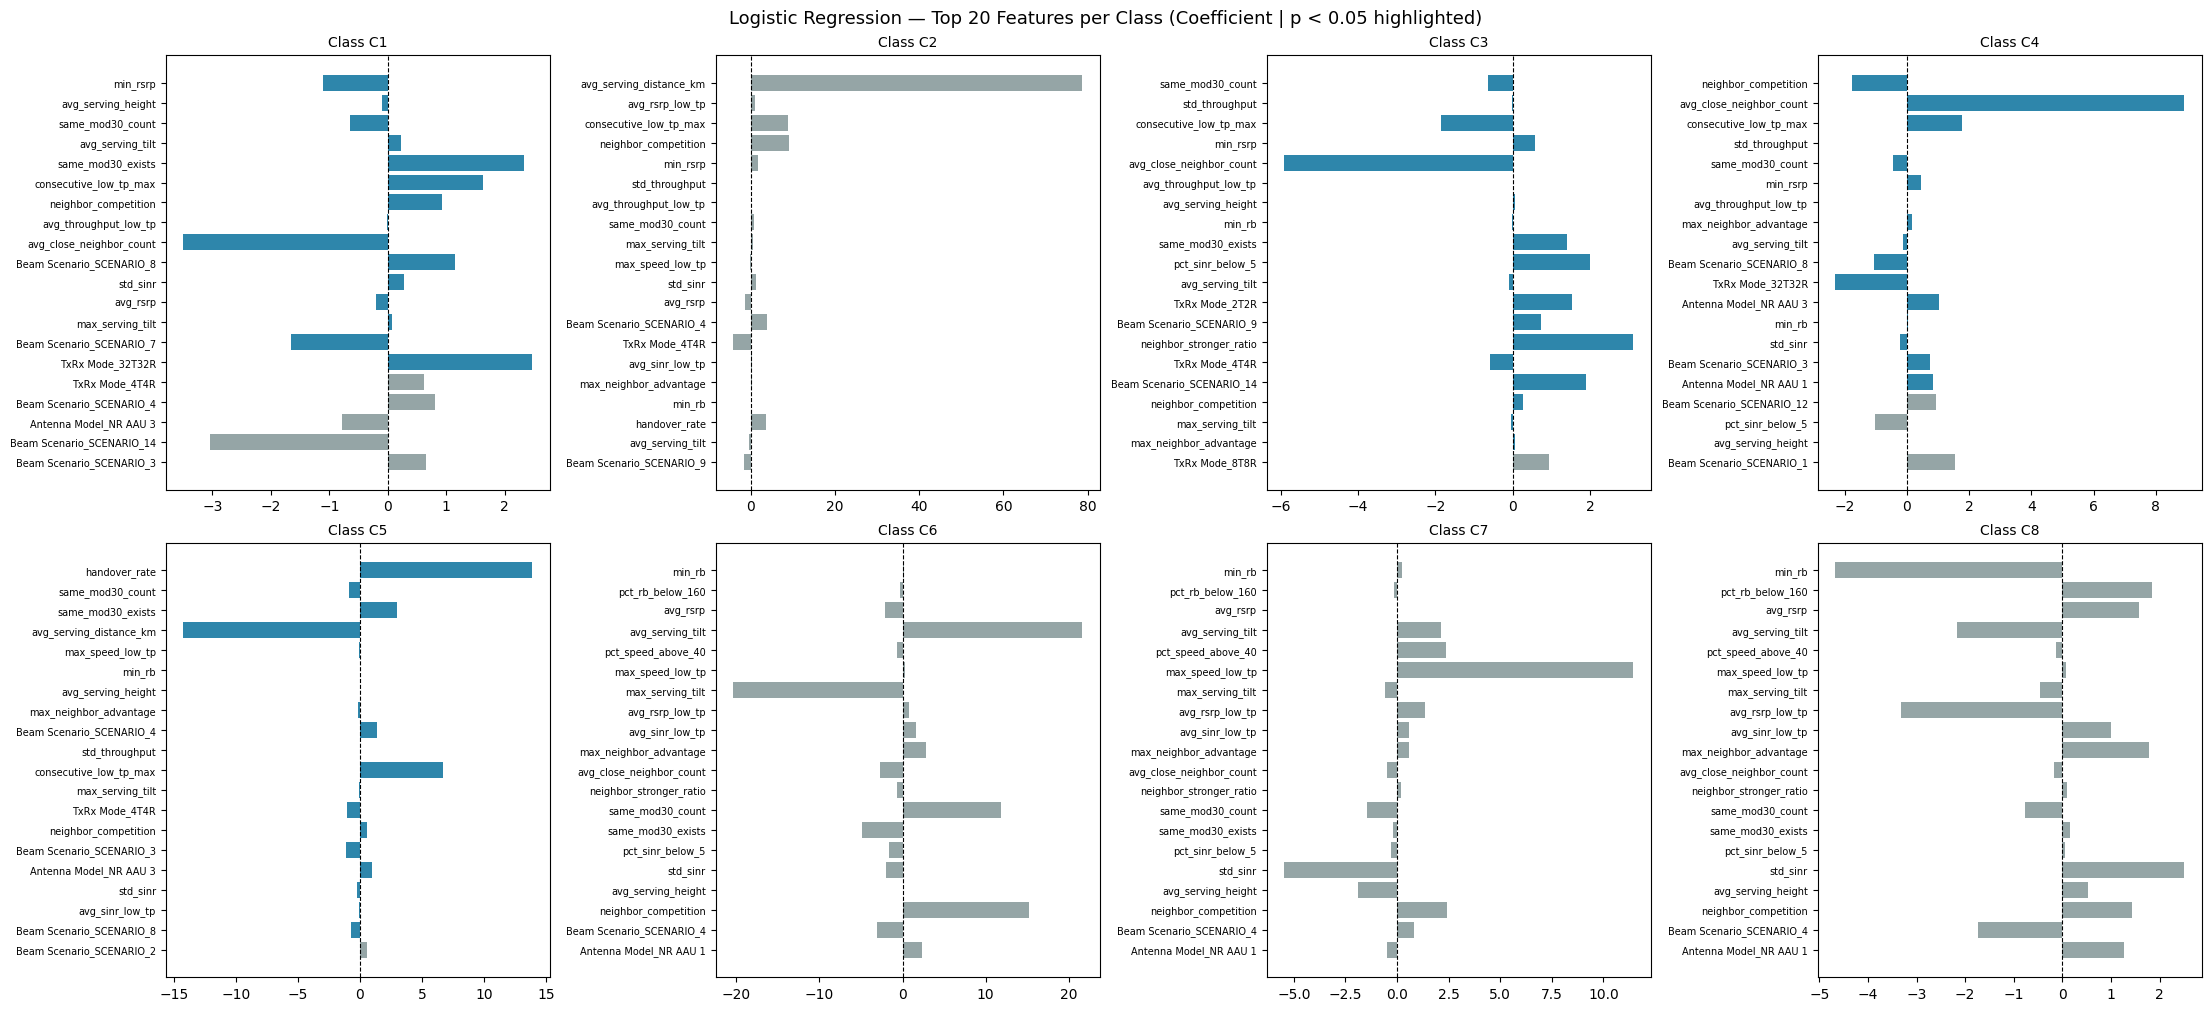

Plot saved: logit_coef_plot.png


In [40]:
def plot_logit_coef(summaries, top_n=20, color="#2E86AB"):
    classes = list(summaries.keys())
    n_cls = len(classes)
    fig, axes = plt.subplots(2, 4, figsize=(22, 10), constrained_layout=True)
    fig.suptitle(f"Logistic Regression — Top {top_n} Features per Class (Coefficient | p < 0.05 highlighted)", fontsize=13)

    for ax, cls in zip(axes.flat, classes):
        df = summaries[cls].head(top_n).iloc[::-1]
        colors = [color if s else "#95a5a6" for s in df["significant"]]
        ax.barh(df.index, df["coef"], color=colors)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"Class {cls}", fontsize=10)
        ax.tick_params(axis="y", labelsize=7)

    for ax in axes.flat[n_cls:]:
        ax.set_visible(False)

    plt.savefig("logit_coef_plot.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved: logit_coef_plot.png")

plot_logit_coef(summaries_logit, top_n=20, color="#2E86AB")

## Logistic Regression Databrick Code

In [44]:
C1 = smf.logit('is_C1 ~ min_rb + pct_rb_below_160 + avg_rsrp + avg_serving_tilt + pct_speed_above_40 + max_speed_low_tp + max_serving_tilt + avg_rsrp_low_tp + avg_sinr_low_tp + max_neighbor_advantage + avg_close_neighbor_count + neighbor_stronger_ratio + same_mod30_count + same_mod30_exists + pct_sinr_below_5 + std_sinr + avg_serving_height + neighbor_competition + Q("Beam Scenario_SCENARIO_4") + Q("Antenna Model_NR AAU 1") + Q("Beam Scenario_SCENARIO_13") + Q("TxRx Mode_32T32R") + Q("Antenna Model_NR AAU 3") + Q("Beam Scenario_SCENARIO_3") + min_rsrp + avg_throughput_low_tp + Q("Beam Scenario_SCENARIO_1") + Q("Beam Scenario_SCENARIO_8") + Q("Beam Scenario_SCENARIO_12") + handover_rate + Q("Beam Scenario_SCENARIO_9") + Q("Beam Scenario_SCENARIO_7") + Q("Beam Scenario_SCENARIO_2") + Q("TxRx Mode_4T4R") + std_throughput + consecutive_low_tp_max + Q("TxRx Mode_2T2R") + avg_serving_distance_km + Q("TxRx Mode_8T8R") + Q("Beam Scenario_SCENARIO_14") + throughput_per_sinr', data=telecom_C1).fit()
print(C1.summary())

         Current function value: 0.058225
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                  is_C1   No. Observations:                 2400
Model:                          Logit   Df Residuals:                     2358
Method:                           MLE   Df Model:                           41
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.8320
Time:                        20:04:50   Log-Likelihood:                -139.74
converged:                      False   LL-Null:                       -831.64
Covariance Type:            nonrobust   LLR p-value:                1.491e-263
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                        -97.7440   3.78e+04     -0.003      0.998   -7.42e+04     7.4e+04
min_r